In [2]:
install.packages(c(
  "tidyverse",
  "psych",
  "GPArotation",
  "nFactors",
  "corrplot",
  "reshape2",
  "lavaan",
  "semTools",
    "blavaan",
    "bayesplot",
    "posterior"
))

Instalando pacotes em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'tidyverse' successfully unpacked and MD5 sums checked
package 'psych' successfully unpacked and MD5 sums checked
package 'GPArotation' successfully unpacked and MD5 sums checked
package 'nFactors' successfully unpacked and MD5 sums checked
package 'corrplot' successfully unpacked and MD5 sums checked
package 'reshape2' successfully unpacked and MD5 sums checked


Warning message:
"não foi possível remover a instalação prévia do pacote 'reshape2'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\Maxwell\AppData\Local\R\win-library\4.6\00LOCK\reshape2\libs\x64\reshape2.dll to C:\Users\Maxwell\AppData\Local\R\win-library\4.6\reshape2\libs\x64\reshape2.dll: Permission denied"
Warning message:
"'reshape2' restaurado"


package 'lavaan' successfully unpacked and MD5 sums checked
package 'semTools' successfully unpacked and MD5 sums checked
package 'blavaan' successfully unpacked and MD5 sums checked


Warning message:
"não foi possível remover a instalação prévia do pacote 'blavaan'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\Maxwell\AppData\Local\R\win-library\4.6\00LOCK\blavaan\libs\x64\blavaan.dll to C:\Users\Maxwell\AppData\Local\R\win-library\4.6\blavaan\libs\x64\blavaan.dll: Permission denied"
Warning message:
"'blavaan' restaurado"


package 'bayesplot' successfully unpacked and MD5 sums checked
package 'posterior' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpMPz9sE\downloaded_packages


In [3]:
install.packages("QuickJSR", type = "source")

Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)

Warning message in install.packages("QuickJSR", type = "source"):
"instalação do pacote 'QuickJSR' teve um status de saída não zero"


In [65]:
install.packages("runjags")

Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'runjags' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpMPz9sE\downloaded_packages


In [126]:
install.packages("brms")

Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'brms' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpMPz9sE\downloaded_packages


In [131]:
install.packages("Brobdingnag")

Instalando pacote em 'C:/Users/Maxwell/AppData/Local/R/win-library/4.6'
(como 'lib' não foi especificado)



package 'Brobdingnag' successfully unpacked and MD5 sums checked

Os pacotes binários baixados estão em
	C:\Users\Maxwell\AppData\Local\Temp\RtmpMPz9sE\downloaded_packages


In [132]:
library(brms)

Loading 'brms' package (version 2.23.0). Useful instructions
can be found by typing help('brms'). A more detailed introduction
to the package is available through vignette('brms_overview').


Anexando pacote: 'brms'


O seguinte objeto é mascarado por 'package:rstan':

    loo


O seguinte objeto é mascarado por 'package:bayesplot':

    rhat


O seguinte objeto é mascarado por 'package:psych':

    cs


O seguinte objeto é mascarado por 'package:stats':

    ar




In [129]:
library(tidyverse)

library(psych)
library(GPArotation)

library(nFactors)

library(corrplot)

library(reshape2)

library(lavaan)
library(semTools)

library(blavaan)
library(bayesplot)

In [66]:
library(dplyr)

In [69]:
library(runjags)

In [74]:
library(rjags)

Carregando pacotes exigidos: coda

Linked to JAGS 4.3.2

Loaded modules: basemod,bugs



In [108]:
library(rstan)

Carregando pacotes exigidos: StanHeaders


rstan version 2.32.7 (Stan version 2.32.2)


For execution on a local, multicore CPU with excess RAM we recommend calling
options(mc.cores = parallel::detectCores()).
To avoid recompilation of unchanged Stan programs, we recommend calling
rstan_options(auto_write = TRUE)
For within-chain threading using `reduce_sum()` or `map_rect()` Stan functions,
change `threads_per_chain` option:
rstan_options(threads_per_chain = 1)


Do not specify '-march=native' in 'LOCAL_CPPFLAGS' or a Makevars file


Anexando pacote: 'rstan'


O seguinte objeto é mascarado por 'package:coda':

    traceplot


O seguinte objeto é mascarado por 'package:runjags':

    extract


O seguinte objeto é mascarado por 'package:psych':

    lookup


O seguinte objeto é mascarado por 'package:tidyr':

    extract




In [6]:
efa_data_raw <- read.delim(
  "adequacy-c.txt",
  check.names = FALSE
)

names(efa_data_raw) <- gsub(
  "\\.+",
  "_",
  names(efa_data_raw)
)

In [7]:
# Variáveis dos fatores F1 e F4
vars_f1_f4 <- c(
  # F1
  "Science_Level",
  "Reading_Comprehension_Level",
  "Writing_Level",
  "Active_Learning_Level",
  "Systems_Evaluation_Level",
  "Speaking_Level",
  "Systems_Analysis_Level",
  "Operations_Analysis_Level",
  "Critical_Thinking_Level",
  "Learning_Strategies_Level",

  # F4
  "Operation_and_Control_Level",
  "Troubleshooting_Level",
  "Repairing_Level",
  "Equipment_Maintenance_Level",
  "Operations_Monitoring_Level",
  "Quality_Control_Analysis_Level",
  "Equipment_Selection_Level"
)

# Lista completa das variáveis de habilidades
skills_cols <- c(
  "Reading_Comprehension_Level",
  "Active_Listening_Level",
  "Writing_Level",
  "Speaking_Level",
  "Mathematical_Reasoning_Level",
  "Science_Level",
  "Critical_Thinking_Level",
  "Active_Learning_Level",
  "Learning_Strategies_Level",
  "Monitoring_Level",
  "Social_Perceptiveness_Level",
  "Coordination_Level",
  "Persuasion_Level",
  "Negotiation_Level",
  "Instructing_Level",
  "Service_Orientation_Level",
  "Complex_Problem_Solving_Level",
  "Operations_Analysis_Level",
  "Technology_Design_Level",
  "Installation_Level",
  "Programming_Level",
  "Operations_Monitoring_Level",
  "Operation_and_Control_Level",
  "Equipment_Maintenance_Level",
  "Troubleshooting_Level",
  "Repairing_Level",
  "Quality_Control_Analysis_Level",
  "Judgment_and_Decision_Making_Level",
  "Systems_Analysis_Level",
  "Systems_Evaluation_Level",
  "Time_Management_Level",
  "Management_of_Financial_Resources_Level",
  "Management_of_Material_Resources_Level",
  "Management_of_Personnel_Resources_Level",
  "Equipment_Selection_Level"
)

# Variáveis a excluir
cols_excluir <- setdiff(skills_cols, vars_f1_f4)

# Excluir da base
efa_data_raw <- efa_data_raw %>%
  dplyr::select(-all_of(cols_excluir))

In [8]:
id_cols <- c(
  "O_NET_SOC_Code",
  "Title",
  "Version_Year"
)

skill_vars <- setdiff(
  names(efa_data_raw),
  id_cols
)

efa_global <- efa_data_raw %>%
  select(all_of(skill_vars))

### Solução 2 Fatores (Revisado por ESEM)

In [12]:
efa <- fa(
  efa_global,
  nfactors = 2,
  fm = "minres",
  rotate = "oblimin"
)

print(
  efa,
  sort = TRUE,
  cut = .30
)

Factor Analysis using method =  minres
Call: fa(r = efa_global, nfactors = 2, rotate = "oblimin", fm = "minres")
Standardized loadings (pattern matrix) based upon correlation matrix
                               item   MR1   MR2   h2    u2 com
Systems_Evaluation_Level         16  0.96       0.86 0.143 1.0
Active_Learning_Level             6  0.95       0.93 0.072 1.0
Systems_Analysis_Level           15  0.95       0.84 0.162 1.0
Critical_Thinking_Level           5  0.92       0.88 0.118 1.0
Reading_Comprehension_Level       1  0.90       0.91 0.095 1.0
Writing_Level                     2  0.87       0.90 0.101 1.1
Learning_Strategies_Level         7  0.84       0.74 0.256 1.0
Speaking_Level                    3  0.82       0.89 0.107 1.2
Science_Level                     4  0.79       0.57 0.429 1.3
Operations_Analysis_Level         8  0.78       0.56 0.436 1.1
Troubleshooting_Level            12        0.97 0.95 0.053 1.0
Operations_Monitoring_Level       9        0.92 0.82 0.182 1.0

### Interpretar a EFA

In [13]:
efa$communality

Reading_Comprehension_Level                  Writing_Level 
                     0.9053163                      0.8987883 
                Speaking_Level                  Science_Level 
                     0.8931036                      0.5710394 
       Critical_Thinking_Level          Active_Learning_Level 
                     0.8819465                      0.9276738 
     Learning_Strategies_Level      Operations_Analysis_Level 
                     0.7438731                      0.5641952 
   Operations_Monitoring_Level    Operation_and_Control_Level 
                     0.8178908                      0.8012422 
   Equipment_Maintenance_Level          Troubleshooting_Level 
                     0.8502722                      0.9469428 
               Repairing_Level Quality_Control_Analysis_Level 
                     0.8230185                      0.7616847 
        Systems_Analysis_Level       Systems_Evaluation_Level 
                     0.8381159                      0.8567242 
     Equipment_Selection_Level 
                     0.8403929

In [14]:
efa$r.scores

1.000000,-0.303702
-0.303702,1.000000


In [15]:
efa$STATISTIC   # Qui-quadrado
efa$dof         # Graus de liberdade
efa$PVAL        # p-valor

[1] 15065.56

[1] 103

[1] 0

### Confiabilidade (EFA)

In [17]:
loadings <- as.data.frame(unclass(efa$loadings))
print(loadings)

                                        MR1         MR2
Reading_Comprehension_Level     0.901110392 -0.13857973
Writing_Level                   0.867164299 -0.20422721
Speaking_Level                  0.824454097 -0.27806598
Science_Level                   0.789269206  0.28850613
Critical_Thinking_Level         0.918781061 -0.06220355
Active_Learning_Level           0.947556797 -0.04877757
Learning_Strategies_Level       0.844251808 -0.05586475
Operations_Analysis_Level       0.780018585  0.13480954
Operations_Monitoring_Level     0.041213896  0.91574628
Operation_and_Control_Level    -0.134561758  0.84591943
Equipment_Maintenance_Level    -0.101908997  0.88671135
Troubleshooting_Level          -0.018556588  0.96744197
Repairing_Level                -0.081049033  0.87984525
Quality_Control_Analysis_Level  0.164373798  0.90729015
Systems_Analysis_Level          0.946132891  0.13319898
Systems_Evaluation_Level        0.956839577  0.13628158
Equipment_Selection_Level      -0.003339031  0.9

In [18]:
max_factor <- apply(loadings, 1, function(x) {
  which.max(abs(x))
})

max_loading <- apply(loadings, 1, function(x) {
  max(abs(x))
})

item_factor <- data.frame(
  item = rownames(loadings),
  fator = max_factor,
  carga = max_loading
)

item_factor_filtrado <- subset(item_factor, carga >= 0.50)

itens_por_fator <- split(
  item_factor_filtrado$item,
  item_factor_filtrado$fator
)

for (i in 1:length(itens_por_fator)) {
  assign(paste0("F", i), itens_por_fator[[i]])
}

itens_por_fator

$`1`
 [1] "Reading_Comprehension_Level" "Writing_Level"              
 [3] "Speaking_Level"              "Science_Level"              
 [5] "Critical_Thinking_Level"     "Active_Learning_Level"      
 [7] "Learning_Strategies_Level"   "Operations_Analysis_Level"  
 [9] "Systems_Analysis_Level"      "Systems_Evaluation_Level"   

$`2`
[1] "Operations_Monitoring_Level"    "Operation_and_Control_Level"   
[3] "Equipment_Maintenance_Level"    "Troubleshooting_Level"         
[5] "Repairing_Level"                "Quality_Control_Analysis_Level"
[7] "Equipment_Selection_Level"

Number of categories should be increased  in order to count frequencies. 

Number of categories should be increased  in order to count frequencies. 



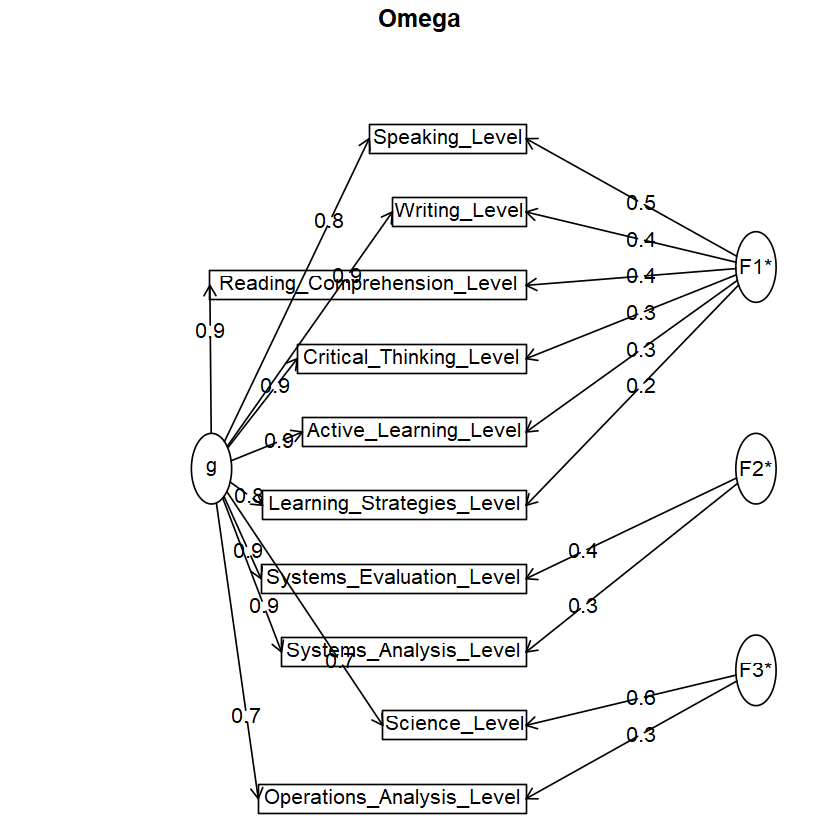

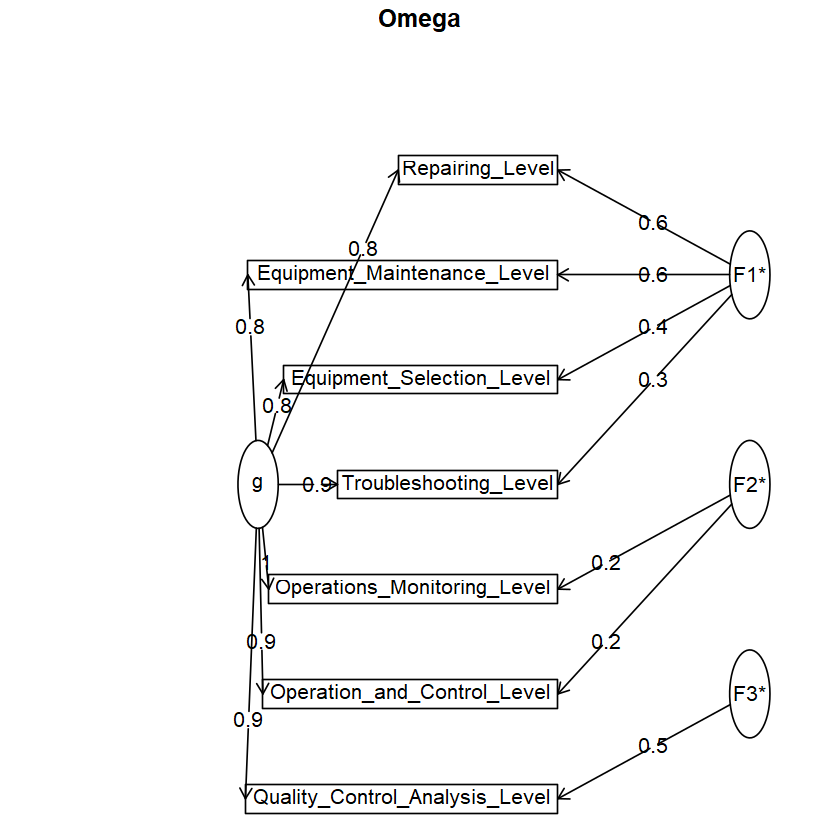

In [22]:
resultados_confiabilidade <- lapply(itens_por_fator, function(itens) {
  list(
    alpha = psych::alpha(efa_global[, itens]),
    omega = psych::omega(efa_global[, itens], fm = "minres")
  )
})

In [24]:
tabela_confiabilidade <- data.frame(
  Fator = paste0("F", seq_along(resultados_confiabilidade)),

  Itens = sapply(itens_por_fator, length),

  Alfa = round(
    sapply(
      resultados_confiabilidade,
      function(x) x$alpha$total$raw_alpha
    ),
    3
  ),

  Omega = round(
    sapply(
      resultados_confiabilidade,
      function(x) x$omega$omega.tot
    ),
    3
  )
)

tabela_confiabilidade

,Fator,Itens,Alfa,Omega
,<chr>,<int>,<dbl>,<dbl>
1,F1,10,0.961,0.983
2,F2,7,0.969,0.990


### Modelo CFA

In [25]:
modelo_cfa <- paste(
  sapply(names(itens_por_fator), function(f) {
    paste0(f, " =~ ", paste(itens_por_fator[[f]], collapse = " + "))
  }),
  collapse = "\n"
)

cat(modelo_cfa)

1 =~ Reading_Comprehension_Level + Writing_Level + Speaking_Level + Science_Level + Critical_Thinking_Level + Active_Learning_Level + Learning_Strategies_Level + Operations_Analysis_Level + Systems_Analysis_Level + Systems_Evaluation_Level
2 =~ Operations_Monitoring_Level + Operation_and_Control_Level + Equipment_Maintenance_Level + Troubleshooting_Level + Repairing_Level + Quality_Control_Analysis_Level + Equipment_Selection_Level

In [28]:
modelo_cfa <- '
Soft =~ 
    Reading_Comprehension_Level + 
    Writing_Level + 
    Speaking_Level + 
    Science_Level + 
    Critical_Thinking_Level + 
    Active_Learning_Level + 
    Learning_Strategies_Level + 
    Operations_Analysis_Level + 
    Systems_Analysis_Level + 
    Systems_Evaluation_Level

Hard =~ 
    Operations_Monitoring_Level + 
    Operation_and_Control_Level + 
    Equipment_Maintenance_Level + 
    Troubleshooting_Level + 
    Repairing_Level + 
    Quality_Control_Analysis_Level + 
    Equipment_Selection_Level
'

In [29]:
ajuste_cfa <- cfa(
  model = modelo_cfa,
  data = efa_global,
  estimator = "MLR",
  std.lv = TRUE
)

fitMeasures(
  ajuste_cfa,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower","rmsea.ci.upper","srmr")
)

chisq             df         pvalue            cfi            tli 
     18095.060        118.000          0.000          0.795          0.763 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.223          0.221          0.226          0.115

### EFA longitudinal por ano

In [30]:
years <- sort(
  unique(efa_data_raw$Version_Year)
)

efa_by_year <- list()

for(y in years){

  temp <- efa_data_raw %>%
    filter(Version_Year == y) %>%
    select(all_of(skill_vars))

  efa_by_year[[as.character(y)]] <- fa(
    temp,
    nfactors = 2,
    fm = "minres",
    rotate = "oblimin"
  )
}

efa_by_year

$`2017`
Factor Analysis using method =  minres
Call: fa(r = temp, nfactors = 2, rotate = "oblimin", fm = "minres")
Standardized loadings (pattern matrix) based upon correlation matrix
                                 MR1   MR2   h2    u2 com
Reading_Comprehension_Level     0.90 -0.13 0.90 0.097 1.0
Writing_Level                   0.87 -0.20 0.90 0.104 1.1
Speaking_Level                  0.83 -0.27 0.90 0.105 1.2
Science_Level                   0.78  0.27 0.56 0.443 1.2
Critical_Thinking_Level         0.92 -0.06 0.88 0.117 1.0
Active_Learning_Level           0.95 -0.03 0.93 0.070 1.0
Learning_Strategies_Level       0.85 -0.04 0.75 0.249 1.0
Operations_Analysis_Level       0.77  0.12 0.55 0.453 1.0
Operations_Monitoring_Level     0.04  0.90 0.80 0.204 1.0
Operation_and_Control_Level    -0.13  0.84 0.78 0.216 1.1
Equipment_Maintenance_Level    -0.10  0.88 0.85 0.153 1.0
Troubleshooting_Level          -0.02  0.96 0.94 0.061 1.0
Repairing_Level                -0.09  0.88 0.82 0.176 1.0
Qual

### Congruência de Tucker

In [31]:
factor.congruence(
  efa_by_year[["2017"]],
  efa_by_year[["2019"]]
)

factor.congruence(
  efa_by_year[["2019"]],
  efa_by_year[["2021"]]
)

factor.congruence(
  efa_by_year[["2021"]],
  efa_by_year[["2023"]]
)

factor.congruence(
  efa_by_year[["2023"]],
  efa_by_year[["2025"]]
)

,MR1,MR2
MR1,1.00,-0.03
MR2,-0.03,1.00


,MR2,MR1
MR1,1.00,-0.03
MR2,-0.03,1.00


,MR2,MR1
MR2,1.00,-0.03
MR1,-0.03,1.00


,MR2,MR1
MR2,1.00,-0.03
MR1,-0.03,1.00


In [32]:
print(factor.congruence(efa_by_year))

      MR1   MR2   MR1   MR2   MR2   MR1   MR2   MR1   MR2   MR1
MR1  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03
MR2 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00
MR1  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03
MR2 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00
MR2  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03
MR1 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00
MR2  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03
MR1 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00
MR2  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03
MR1 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00 -0.03  1.00


### Carga Fatorial por Ano

In [35]:
loadings_year <- lapply(
  efa_by_year,
  function(x){
    as.data.frame(unclass(x$loadings))
  }
)

print(loadings_year)

$`2017`
                                       MR1         MR2
Reading_Comprehension_Level     0.90157074 -0.13365340
Writing_Level                   0.86847762 -0.19779745
Speaking_Level                  0.82677935 -0.27493445
Science_Level                   0.78143665  0.27157921
Critical_Thinking_Level         0.91956803 -0.06172908
Active_Learning_Level           0.95470058 -0.03042254
Learning_Strategies_Level       0.85290312 -0.04206503
Operations_Analysis_Level       0.76594772  0.11591097
Operations_Monitoring_Level     0.03728939  0.90271881
Operation_and_Control_Level    -0.13497846  0.83558070
Equipment_Maintenance_Level    -0.10212546  0.88462893
Troubleshooting_Level          -0.02094281  0.96274631
Repairing_Level                -0.08643513  0.87783429
Quality_Control_Analysis_Level  0.20233322  0.89292301
Systems_Analysis_Level          0.93717712  0.12548469
Systems_Evaluation_Level        0.95372591  0.13924216
Equipment_Selection_Level      -0.01809017  0.91011381

$

In [36]:
cargas_long <- bind_rows(
  lapply(names(loadings_year), function(y){

    loadings_year[[y]] %>%
      tibble::rownames_to_column("skill") %>%
      pivot_longer(
        starts_with("MR"),
        names_to = "factor",
        values_to = "loading"
      ) %>%
      mutate(year = y)

  })
)

print(cargas_long, n = Inf, width = Inf)

# A tibble: 170 × 4
    skill                          factor  loading year 
    <chr>                          <chr>     <dbl> <chr>
  1 Reading_Comprehension_Level    MR1     0.902   2017 
  2 Reading_Comprehension_Level    MR2    -0.134   2017 
  3 Writing_Level                  MR1     0.868   2017 
  4 Writing_Level                  MR2    -0.198   2017 
  5 Speaking_Level                 MR1     0.827   2017 
  6 Speaking_Level                 MR2    -0.275   2017 
  7 Science_Level                  MR1     0.781   2017 
  8 Science_Level                  MR2     0.272   2017 
  9 Critical_Thinking_Level        MR1     0.920   2017 
 10 Critical_Thinking_Level        MR2    -0.0617  2017 
 11 Active_Learning_Level          MR1     0.955   2017 
 12 Active_Learning_Level          MR2    -0.0304  2017 
 13 Learning_Strategies_Level      MR1     0.853   2017 
 14 Learning_Strategies_Level      MR2    -0.0421  2017 
 15 Operations_Analysis_Level      MR1     0.766   2017 
 16 Operati

### EFAL Robusta

In [39]:
loadings_year <- lapply(efa_by_year, function(x){

  L <- as.data.frame(unclass(x$loadings))

  # padronizar nomes dos fatores
  colnames(L) <- c("F1","F2")

  # garantir orientação consistente
  if(mean(L$F1[1:10]) < mean(L$F2[1:10])){
    L <- L[, c("F2","F1")]
    colnames(L) <- c("F1","F2")
  }

  as.matrix(L)
})

In [40]:
anos <- names(loadings_year)

congruencia <- matrix(
  NA,
  nrow = length(anos),
  ncol = length(anos),
  dimnames = list(anos, anos)
)

for(i in seq_along(anos)){

  for(j in seq_along(anos)){

    phi <- factor.congruence(
      loadings_year[[anos[i]]],
      loadings_year[[anos[j]]]
    )

    congruencia[i,j] <- mean(diag(phi))
  }
}

round(congruencia, 4)

,2017,2019,2021,2023,2025
2017,1,1,1,1,1
2019,1,1,1,1,1
2021,1,1,1,1,1
2023,1,1,1,1,1
2025,1,1,1,1,1


In [43]:
comparacoes <- list()

for(i in 1:(length(anos)-1)){

  phi <- factor.congruence(
    loadings_year[[anos[i]]],
    loadings_year[[anos[i+1]]]
  )

  comparacoes[[paste0(
    anos[i], "_",
    anos[i+1]
  )]] <- phi
}

comparacoes

,F1,F2
F1,1.00,-0.03
F2,-0.03,1.00
,F1,F2
F1,1.00,-0.03
F2,-0.03,1.00
,F1,F2
F1,1.00,-0.03
F2,-0.03,1.00
,F1,F2
F1,1.00,-0.03


In [44]:
stability <- data.frame()

for(i in 1:(length(anos)-1)){

  L1 <- loadings_year[[anos[i]]]
  L2 <- loadings_year[[anos[i+1]]]

  r1 <- cor(L1[,1], L2[,1])
  r2 <- cor(L1[,2], L2[,2])

  stability <- rbind(
    stability,
    data.frame(
      Comparacao = paste(
        anos[i],
        anos[i+1],
        sep = "-"
      ),
      F1 = r1,
      F2 = r2
    )
  )
}

stability

Comparacao,F1,F2
<chr>,<dbl>,<dbl>
2017-2019,0.9997202,0.9998833
2019-2021,0.9998966,0.9999349
2021-2023,0.9999744,0.9999859
2023-2025,0.9999663,0.9999523


In [45]:
delta <- data.frame()

for(i in 1:(length(anos)-1)){

  L1 <- loadings_year[[anos[i]]]
  L2 <- loadings_year[[anos[i+1]]]

  delta <- rbind(
    delta,
    data.frame(
      Comparacao = paste(
        anos[i],
        anos[i+1],
        sep="-"
      ),
      Delta_F1 = mean(abs(L1[,1] - L2[,1])),
      Delta_F2 = mean(abs(L1[,2] - L2[,2]))
    )
  )
}

delta

Comparacao,Delta_F1,Delta_F2
<chr>,<dbl>,<dbl>
2017-2019,0.005649586,0.006290323
2019-2021,0.004559727,0.005083341
2021-2023,0.002439697,0.003133232
2023-2025,0.003081986,0.003735832


### CFA Longitudinal

In [46]:
fit_configural <- cfa(
  modelo_cfa,
  data = efa_data_raw,
  group = "Version_Year",
  estimator = "MLR",
  std.lv = TRUE
)

fitMeasures(
  fit_configural,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower","rmsea.ci.upper","srmr")
)

chisq             df         pvalue            cfi            tli 
     18271.583        590.000          0.000          0.797          0.766 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.222          0.219          0.224          0.109

In [47]:
fit_metric <- cfa(
  modelo_cfa,
  data = efa_data_raw,
  group = "Version_Year",
  estimator = "MLR",
  std.lv = TRUE,
  group.equal = "loadings"
)

In [48]:
fit_scalar <- cfa(
  modelo_cfa,
  data = efa_data_raw,
  group = "Version_Year",
  estimator = "MLR",
  std.lv = TRUE,
  group.equal = c(
    "loadings",
    "intercepts"
  )
)

In [49]:
fit_strict <- cfa(
  modelo_cfa,
  data = efa_data_raw,
  group = "Version_Year",
  estimator = "MLR",
  std.lv = TRUE,
  group.equal = c(
    "loadings",
    "intercepts",
    "residuals"
  )
)

In [56]:
avTestLRT(
  fit_configural,
  fit_metric,
  fit_scalar,
  fit_strict
)

ERROR: Error in avTestLRT(fit_configural, fit_metric, fit_scalar, fit_strict): não foi possível encontrar a função "avTestLRT"


In [51]:
indices <- rbind(

  Configural = fitMeasures(
    fit_configural,
    c("cfi","tli","rmsea","srmr")
  ),

  Metric = fitMeasures(
    fit_metric,
    c("cfi","tli","rmsea","srmr")
  ),

  Scalar = fitMeasures(
    fit_scalar,
    c("cfi","tli","rmsea","srmr")
  ),

  Strict = fitMeasures(
    fit_strict,
    c("cfi","tli","rmsea","srmr")
  )
)

round(indices, 3)

,cfi,tli,rmsea,srmr
Configural,0.797,0.766,0.222,0.109
Metric,0.798,0.788,0.211,0.109
Scalar,0.798,0.807,0.202,0.109
Strict,0.798,0.824,0.192,0.109


In [52]:
delta_cfi <- c(
  NA,
  diff(indices[, "cfi"])
)

data.frame(
  Modelo = rownames(indices),
  CFI = indices[, "cfi"],
  Delta_CFI = delta_cfi
)

,Modelo,CFI,Delta_CFI
,<chr>,<dbl>,<dbl>
Configural,Configural,0.7972579,NA
Metric,Metric,0.7977940,0.0005361507
Scalar,Scalar,0.7981980,0.0004039800
Strict,Strict,0.7984814,0.0002834639


### CFA por Ano

In [53]:
cfa_year <- list()

for(y in years){

  temp <- efa_data_raw %>%
    filter(Version_Year == y)

  cfa_year[[as.character(y)]] <- cfa(
    modelo_cfa,
    data = temp,
    estimator = "MLR",
    std.lv = TRUE
  )
}

In [54]:
fit_anos <- lapply(cfa_year, fitMeasures,
                   c("cfi","tli","rmsea","srmr"))

bind_rows(fit_anos, .id = "Ano")

Ano,cfi,tli,rmsea,srmr
<chr>,<lvn.vctr>,<lvn.vctr>,<lvn.vctr>,<lvn.vctr>
2017,0.8076956,0.7783610,0.2123921,0.1128889
2019,0.7980662,0.7672627,0.2198932,0.1129713
2021,0.7937174,0.7622505,0.2242359,0.1157158
2023,0.7930014,0.7614253,0.2261988,0.1162688
2025,0.7943108,0.7629345,0.2252436,0.1162544


### ESEM Longitudinal

In [96]:
# 1. Filtrar e preparar o dataset unificado (long format)
esem_data <- efa_data_raw %>%
  filter(Version_Year %in% c(2017, 2019, 2021, 2023, 2025)) %>%
  select(Version_Year, all_of(skill_vars))

# Garantir que o ano seja tratado como grupo/fator
esem_data$Version_Year <- as.factor(esem_data$Version_Year)

In [97]:
modelo_esem <- '
  # Bloco EFA para o Fator Soft (f1) e Hard (f2)
  efa("block1")*Soft + efa("block1")*Hard =~ 
    Reading_Comprehension_Level + 
    Writing_Level + 
    Speaking_Level + 
    Science_Level + 
    Critical_Thinking_Level + 
    Active_Learning_Level + 
    Learning_Strategies_Level + 
    Operations_Analysis_Level + 
    Systems_Analysis_Level + 
    Systems_Evaluation_Level +
    Operations_Monitoring_Level + 
    Operation_and_Control_Level + 
    Equipment_Maintenance_Level + 
    Troubleshooting_Level + 
    Repairing_Level + 
    Quality_Control_Analysis_Level + 
    Equipment_Selection_Level
'

In [98]:
# ----------------------------------------------------
# PASSO 1: Invariância Configural (Estrutura igual entre os anos)
# ----------------------------------------------------
fit_configural_esem <- cfa(
  model = modelo_esem, 
  data = esem_data, 
  group = "Version_Year",
  rotation = "oblimin", # Aplica a rotação oblimin nas cargas cruzadas
  estimator = "MLR"     # Recomendado para dados O*NET (robusto a não-normalidade)
)

fitMeasures(
  fit_configural_esem,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower","rmsea.ci.upper","srmr")
)

chisq             df         pvalue            cfi            tli 
     15073.985        515.000          0.000          0.833          0.780 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.215          0.212          0.218          0.031

In [99]:
# ----------------------------------------------------
# PASSO 2: Invariância Métrica (Cargas fatoriais iguais entre os anos)
# ----------------------------------------------------
fit_metric_esem <- cfa(
  model = modelo_esem, 
  data = esem_data, 
  group = "Version_Year",
  group.equal = "loadings", # Força a igualdade das cargas do bloco EFA
  rotation = "oblimin",
  estimator = "MLR"
)

fitMeasures(
  fit_metric_esem,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower","rmsea.ci.upper","srmr")
)

chisq             df         pvalue            cfi            tli 
     15103.712        635.000          0.000          0.834          0.822 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.193          0.191          0.196          0.032

In [100]:
# ----------------------------------------------------
# PASSO 3: Invariância Escalar (Interceptos iguais entre os anos)
# ----------------------------------------------------
fit_scalar_esem <- cfa(
  model = modelo_esem, 
  data = esem_data, 
  group = "Version_Year",
  group.equal = c("loadings", "intercepts"), 
  rotation = "oblimin",
  estimator = "MLR"
)

fitMeasures(
  fit_scalar_esem,
  c("chisq","df","pvalue","cfi","tli","rmsea","rmsea.ci.lower","rmsea.ci.upper","srmr")
)

chisq             df         pvalue            cfi            tli 
     15135.543        695.000          0.000          0.834          0.838 
         rmsea rmsea.ci.lower rmsea.ci.upper           srmr 
         0.185          0.182          0.187          0.033

In [101]:
comparacao_cfa <- compareFit(fit_configural, fit_metric, fit_scalar)
print('CFA Longitudinal')
summary(comparacao_cfa)

comparacao_esem <- compareFit(fit_configural_esem, fit_metric_esem, fit_scalar_esem)
print('ESEM Longitudinal')
summary(comparacao_esem)

[1] "CFA Longitudinal"
################### Nested Model Comparison #########################

Scaled Chi-Squared Difference Test (method = "satorra.bentler.2001")

lavaan->unknown():  
   lavaan NOTE: The "Chisq" column contains standard test statistics, not the 
   robust test that should be reported per model. A robust difference test is 
   a function of two standard (not robust) statistics.

                Df   AIC   BIC Chisq Chisq diff RMSEA Df diff Pr(>Chisq)
fit_configural 590 51930 53496 18272                                    
fit_metric     650 51823 53028 18285     12.645     0      60          1
fit_scalar     710 51728 52571 18310     24.781     0      60          1

####################### Model Fit Indices ###########################
               chisq.scaled df.scaled pvalue.scaled rmsea.robust cfi.robust
fit_configural   16381.502†       590          .000        .221       .798 
fit_metric       16486.472        650          .000        .210       .798 
fit_scalar

### B-CFA de 2 Fatores

In [67]:
# Sintaxe B-CFA de 2 Fatores
# Nota: 'prior' define a distribuição a priori para os parâmetros.
# Usamos uma distribuição normal com média 0 e variância muito pequena (0.01) para cargas cruzadas.

modelo_bcfa <- '
  # Fator 1: Soft Skills (Principais)
  Soft =~ Reading_Comprehension_Level + 
          Writing_Level + 
          Speaking_Level + 
          Science_Level + 
          Critical_Thinking_Level + 
          Active_Learning_Level + 
          Learning_Strategies_Level + 
          Operations_Analysis_Level + 
          Systems_Analysis_Level + 
          Systems_Evaluation_Level

  # Fator 2: Hard Skills (Principais)
  Hard =~ Operations_Monitoring_Level + 
          Operation_and_Control_Level + 
          Equipment_Maintenance_Level + 
          Troubleshooting_Level + 
          Repairing_Level + 
          Quality_Control_Analysis_Level + 
          Equipment_Selection_Level

  # --- Cargas Cruzadas Flexíveis (Small-Variance Priors) ---
  # Permitir que itens de Hard carreguem levemente em Soft
  Soft =~ prior("normal(0,0.01)")*Operations_Monitoring_Level +
          prior("normal(0,0.01)")*Operation_and_Control_Level +
          prior("normal(0,0.01)")*Equipment_Maintenance_Level +
          prior("normal(0,0.01)")*Troubleshooting_Level +
          prior("normal(0,0.01)")*Repairing_Level +
          prior("normal(0,0.01)")*Quality_Control_Analysis_Level +
          prior("normal(0,0.01)")*Equipment_Selection_Level

  # Permitir que itens de Soft carreguem levemente em Hard
  Hard =~ prior("normal(0,0.01)")*Reading_Comprehension_Level + 
          prior("normal(0,0.01)")*Writing_Level + 
          prior("normal(0,0.01)")*Speaking_Level + 
          prior("normal(0,0.01)")*Science_Level + 
          prior("normal(0,0.01)")*Critical_Thinking_Level + 
          prior("normal(0,0.01)")*Active_Learning_Level + 
          prior("normal(0,0.01)")*Learning_Strategies_Level + 
          prior("normal(0,0.01)")*Operations_Analysis_Level + 
          prior("normal(0,0.01)")*Systems_Analysis_Level + 
          prior("normal(0,0.01)")*Systems_Evaluation_Level
          
  # Opcional: Se você souber que variáveis como Repairing e Troubleshooting 
  # compartilham forte resíduo, você pode abrir um prior de covariância residual:
  # Repairing ~~ prior("normal(0,0.05)")*Troubleshooting
'

In [149]:
# Execução do modelo Bayesiano
fit_bcfa <- bcfa(
  model = modelo_bcfa, 
  data = esem_data,            # Seu dataset no formato long
  group = "Version_Year",      # Anos das versões
  n.chains = 3,                # Número de cadeias MCMC (mínimo recomendado: 3)
  burnin = 2000,               # Fase de aquecimento para descarte
  sample = 5000,               # Amostras salvas por cadeia
  target = "stan"              # Amostrador (pode mudar para "stan" se tiver rstan)
)

Computing post-estimation metrics (including lvs if requested)...


In [150]:
# 1. Resumo geral e índices de ajuste bayesianos
summary(fit_bcfa, fit.measures = TRUE, standardized = TRUE)

blavaan 0.5.10 ended normally after 5000 iterations

  Estimator                                      BAYES
  Optimization method                             MCMC
  Number of model parameters                       345

  Number of observations per group:                   
    2017                                           610
    2019                                           610
    2021                                           610
    2023                                           610
    2025                                           610

  Statistic                                 MargLogLik         PPP
  Value                                     -27022.013       0.000

Parameter Estimates:



Group 1 [2017]:

Latent Variables:
                   Estimate  Post.SD pi.lower pi.upper   Std.lv  Std.all
  Soft =~                                                               
    Rdng_Cmprhns_L    1.000                               0.657    0.951
    Writing_Level     1.027    0.019 

In [ ]:
# 2. Diagnóstico de Convergência (Crucial!)
# O valor de R-hat (ou PSRF) deve estar muito próximo de 1.00 (< 1.05) para todos os parâmetros.
# Se estiver acima disso, você precisa aumentar o número de 'sample' ou 'burnin'.
blavInspect(fit_bcfa, "psrf") 

In [ ]:
# 3. Plotar os gráficos de densidade e convergência para checagem visual
plot(fit_bcfa, pars = 1:4) # Exemplo com os primeiros 4 parâmetros

In [154]:
blavFitIndices(fit_bcfa)

Warning message:
"
94 (3.1%) p_waic estimates greater than 0.4. We recommend trying loo instead."


Posterior mean (EAP) of devm-based fit indices:

      BRMSEA    BGammaHat adjBGammaHat          BMc 
       0.228        0.886        0.816        0.064 

In [155]:
# Extrair especificamente a matriz de índices de fit
fit_valores <- blavFitIndices(fit_bcfa)

# Isolar a estimativa pontual (média) e o intervalo do BRMSEA
brmsea_media <- fit_valores@brmsea
print(paste("BRMSEA Médio:", round(brmsea_media, 4)))

# Para ver a distribuição completa das iterações do BRMSEA:
# Nota: dependendo da versão do blavaan, as amostras ficam guardadas no slot @indices
brmsea_amostras <- fit_valores@indices$brmsea

# Plotar o gráfico de densidade do seu BRMSEA
plot(density(brmsea_amostras), 
     main = "Distribuição Posterior do BRMSEA", 
     xlab = "Valores de BRMSEA", col = "blue", lwd = 2)
abline(v = 0.06, col = "red", lty = 2, lwd = 1.5) # Linha de corte de bom ajuste

Warning message:
"
94 (3.1%) p_waic estimates greater than 0.4. We recommend trying loo instead."


ERROR: Error: nenhum slot de nome "brmsea" para esse objeto de classe "blavFitIndices"


In [153]:
standardizedPosterior(fit_bcfa)

Soft=~Reading_Comprehension_Level.g1,Soft=~Writing_Level.g1,Soft=~Speaking_Level.g1,Soft=~Science_Level.g1,Soft=~Critical_Thinking_Level.g1,Soft=~Active_Learning_Level.g1,Soft=~Learning_Strategies_Level.g1,Soft=~Operations_Analysis_Level.g1,Soft=~Systems_Analysis_Level.g1,Soft=~Systems_Evaluation_Level.g1,⋯,Systems_Evaluation_Level~1.g5,Operations_Monitoring_Level~1.g5,Operation_and_Control_Level~1.g5,Equipment_Maintenance_Level~1.g5,Troubleshooting_Level~1.g5,Repairing_Level~1.g5,Quality_Control_Analysis_Level~1.g5,Equipment_Selection_Level~1.g5,Soft~1.g5,Hard~1.g5
0.9554389,0.9428499,0.9200037,0.6981958,0.9518394,0.9683964,0.8659025,0.7206450,0.8758045,0.8789185,⋯,0.16841767,-0.03399215,-0.3963479,-0.8989223,-0.6285472,-0.9298312,-0.20998418,-1.143741,0,0
0.9417933,0.9388421,0.9098330,0.6803884,0.9509209,0.9624254,0.8678790,0.6960926,0.8848812,0.8924788,⋯,0.12851309,-0.02914762,-0.3611317,-0.8968190,-0.5698582,-0.8906597,-0.08797407,-1.090930,0,0
0.9531654,0.9345631,0.9203611,0.6929477,0.9459809,0.9652741,0.8673408,0.6982465,0.8899911,0.8966384,⋯,0.17789715,-0.02701757,-0.3271502,-0.8397576,-0.5864163,-0.8511204,-0.16306049,-1.068957,0,0
0.9514630,0.9409029,0.9255755,0.6375258,0.9471971,0.9641342,0.8729500,0.6803867,0.8994175,0.8953525,⋯,0.09925341,-0.01198735,-0.3407497,-0.8632755,-0.5695221,-0.8618268,-0.07709081,-1.119870,0,0
0.9519445,0.9407509,0.9164439,0.6543580,0.9496929,0.9659416,0.8753768,0.7349549,0.8681629,0.8914511,⋯,0.13801394,-0.03622031,-0.3694386,-0.8653637,-0.5868338,-0.8911125,-0.21499710,-1.127506,0,0
0.9543136,0.9374438,0.9179902,0.6889379,0.9456577,0.9690217,0.8648328,0.6757406,0.8760470,0.8856827,⋯,0.09092544,-0.04340491,-0.3114491,-0.8265361,-0.5599630,-0.8311868,-0.05806525,-1.064549,0,0
0.9571229,0.9358605,0.9154469,0.7152097,0.9507977,0.9669040,0.8701901,0.7022547,0.8930085,0.8981873,⋯,0.14106543,0.05066619,-0.3418455,-0.8349694,-0.5350833,-0.8458453,-0.11278156,-1.083360,0,0
0.9495803,0.9423351,0.9156339,0.6704797,0.9449117,0.9598432,0.8578407,0.6902662,0.8632872,0.8819604,⋯,0.17089415,-0.02251650,-0.3087544,-0.8038339,-0.5589706,-0.8313797,-0.08494190,-1.005812,0,0
0.9529397,0.9407477,0.9171931,0.6724700,0.9518590,0.9695489,0.8795285,0.7303007,0.9016003,0.8973357,⋯,0.15189725,-0.04147642,-0.4158627,-0.9101357,-0.6380557,-0.9450494,-0.17044737,-1.165135,0,0
0.9421080,0.9367158,0.9214793,0.7038603,0.9401324,0.9668901,0.8668166,0.6869885,0.8725453,0.8753578,⋯,0.14450115,-0.02500553,-0.3168068,-0.8257624,-0.5668842,-0.8276679,-0.11129598,-1.041060,0,0


### B-ESEM 2 Fatores

In [117]:
modelo_besem <- '

# ==========================================================
  # FATOR 1: SOFT SKILLS (Principais + Cargas Cruzadas)
  # ==========================================================
  Soft =~ Reading_Comprehension_Level +
          Writing_Level +
          Speaking_Level +
          Science_Level +
          Critical_Thinking_Level +
          Active_Learning_Level +
          Learning_Strategies_Level +
          Operations_Analysis_Level +
          Systems_Analysis_Level +
          Systems_Evaluation_Level +
          # Cargas Cruzadas de Hard em Soft:
          prior("normal(0,0.01)")*Operations_Monitoring_Level +
          prior("normal(0,0.01)")*Operation_and_Control_Level +
          prior("normal(0,0.01)")*Equipment_Maintenance_Level +
          prior("normal(0,0.01)")*Troubleshooting_Level +
          prior("normal(0,0.01)")*Repairing_Level +
          prior("normal(0,0.01)")*Quality_Control_Analysis_Level +
          prior("normal(0,0.01)")*Equipment_Selection_Level

  # ==========================================================
  # FATOR 2: HARD SKILLS (Principais + Cargas Cruzadas)
  # ==========================================================
  Hard =~ Operations_Monitoring_Level +
          Operation_and_Control_Level +
          Equipment_Maintenance_Level +
          Troubleshooting_Level +
          Repairing_Level +
          Quality_Control_Analysis_Level +
          Equipment_Selection_Level +
          # Cargas Cruzadas de Soft em Hard:
          prior("normal(0,0.01)")*Reading_Comprehension_Level +
          prior("normal(0,0.01)")*Writing_Level +
          prior("normal(0,0.01)")*Speaking_Level +
          prior("normal(0,0.01)")*Science_Level +
          prior("normal(0,0.01)")*Critical_Thinking_Level +
          prior("normal(0,0.01)")*Active_Learning_Level +
          prior("normal(0,0.01)")*Learning_Strategies_Level +
          prior("normal(0,0.01)")*Operations_Analysis_Level +
          prior("normal(0,0.01)")*Systems_Analysis_Level +
          prior("normal(0,0.01)")*Systems_Evaluation_Level

  # ==========================================================
  # RESIDUAL CORRELATIONS COM SMALL-VARIANCE PRIORS
  # ==========================================================
  # ----- Bloco Técnico / Manutenção -----
  Repairing_Level ~~ prior("normal(0,0.05)")*Equipment_Maintenance_Level
  Repairing_Level ~~ prior("normal(0,0.05)")*Troubleshooting_Level
  Equipment_Maintenance_Level ~~ prior("normal(0,0.05)")*Troubleshooting_Level
  Operation_and_Control_Level ~~ prior("normal(0,0.05)")*Operations_Monitoring_Level

  # ----- Bloco Comunicação -----
  Reading_Comprehension_Level ~~ prior("normal(0,0.05)")*Writing_Level
  Reading_Comprehension_Level ~~ prior("normal(0,0.05)")*Speaking_Level
  Writing_Level ~~ prior("normal(0,0.05)")*Speaking_Level

  # ----- Bloco Sistemas -----
  Systems_Analysis_Level ~~ prior("normal(0,0.05)")*Systems_Evaluation_Level

'

In [118]:
# Execução do modelo Bayesiano (Usando a função correta: bcfa)
fit_besem <- bcfa(
  model = modelo_besem, # A sintaxe com as covariâncias residuais
  data = esem_data,            
  group = "Version_Year",      
  n.chains = 3,                
  burnin = 2000,               
  sample = 5000,               
  target = "stan",             # Ótima escolha! Stan é muito mais rápido e estável que o JAGS
  bcontrol = list(cores = 3)   # DICA: Roda as 3 cadeias em paralelo, economizando muito tempo
)

Warning message in .local(object, ...):
"some chains had errors; consider specifying chains = 1 to debug"
here are whatever error messages were returned



[[1]]
Stan model 'stanmarg' does not contain samples.

[[2]]
Stan model 'stanmarg' does not contain samples.

[[3]]
Stan model 'stanmarg' does not contain samples.

Computing post-estimation metrics (including lvs if requested)...
Stan model 'stanmarg' does not contain samples.


ERROR: Error in rowvec[samppar] <- which(grepl(stanvec[j], names(b.est)) & !(grepl("_c\\[", : substituto tem comprimento zero


### MMHB

In [134]:
# 1. Lista com o nome exato das suas 17 variáveis da O*NET
skills_soft <- c("Reading_Comprehension_Level", "Writing_Level", "Speaking_Level", 
                 "Science_Level", "Critical_Thinking_Level", "Active_Learning_Level", 
                 "Learning_Strategies_Level", "Operations_Analysis_Level", 
                 "Systems_Analysis_Level", "Systems_Evaluation_Level")

skills_hard <- c("Operations_Monitoring_Level", "Operation_and_Control_Level", 
                 "Equipment_Maintenance_Level", "Troubleshooting_Level", 
                 "Repairing_Level", "Quality_Control_Analysis_Level", 
                 "Equipment_Selection_Level")

todas_skills <- c(skills_soft, skills_hard)

# 2. Criar as fórmulas de regressão para cada variável automaticamente
# Definimos que cada skill varia livremente por grupo (ano)
lista_formulas <- lapply(todas_skills, function(skill) {
  bf(as.formula(paste(skill, "~ 0 + (1 | Version_Year)")))
})

# 3. Unificar todas as fórmulas em um objeto de modelo multivariado
# O argumento 'rescor = TRUE' é o segredo: ele estima a matriz de correlação 
# entre todas as variáveis (exatamente o que o ESEM/CFA faz na matriz de covariância)
modelo_multivariado <- do.call(mvbf, c(lista_formulas, list(rescor = TRUE)))

In [135]:
# Definindo priors informativos rígidos para forçar a independência local
# lkj(4) concentra a densidade de probabilidade fortemente ao redor de zero para as correlações
priors_besem <- c(
  set_prior("lkj(4)", class = "rescor")
)

In [137]:
fit_brms_besem <- brm(
  formula = modelo_multivariado,
  data = esem_data,
  prior = priors_besem,
  
  # --- Configurações de Robustez Estatística ---
  chains = 3,               # Padrão ouro de convergência
  iter = 5000,              # Mais iterações para estimativas ultraprecisas
  warmup = 2000,            # Janela de descarte segura para o Stan se estabilizar
  
  # --- Configuração de Hardware ---
  cores = 3,                # Roda as 3 cadeias simultaneamente (uma em cada núcleo)
  
  backend = "rstan",        
  control = list(adapt_delta = 0.95) 
)

Compiling Stan program...

recompiling to avoid crashing R session

Start sampling

Warning message:
"There were 9000 transitions after warmup that exceeded the maximum treedepth. Increase max_treedepth above 10. See
https://mc-stan.org/misc/warnings.html#maximum-treedepth-exceeded"
Warning message:
"Examine the pairs() plot to diagnose sampling problems
"


In [140]:
# 1. Visualizar o sumário de convergência (Rhat deve estar em 1.00)
summary(fit_brms_besem)

 Family: MV(gaussian, gaussian, gaussian, gaussian, gaussian, gaussian, gaussian, gaussian, gaussian, gaussian, gaussian, gaussian, gaussian, gaussian, gaussian, gaussian, gaussian) 
  Links: mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity
         mu = identity 
Formula: Reading_Comprehension_Level ~ 0 + (1 | Version_Year) 
         Writing_Level ~ 0 + (1 | Version_Year) 
         Speaking_Level ~ 0 + (1 | Version_Year) 
         Science_Level ~ 0 + (1 | Version_Year) 
         Critical_Thinking_Level ~ 0 + (1 | Version_Year) 
         Active_Learning_Level ~ 0 + (1 | Version_Year) 
         Learning_Strategies_Level ~ 0 + (1 | Version_Year) 
         Operations_Analysis_Level ~ 

Warning message:
"Argument 'nsamples' is deprecated. Please use argument 'ndraws' instead."
Warning message:
"Argument 'nsamples' is deprecated. Please use argument 'ndraws' instead."


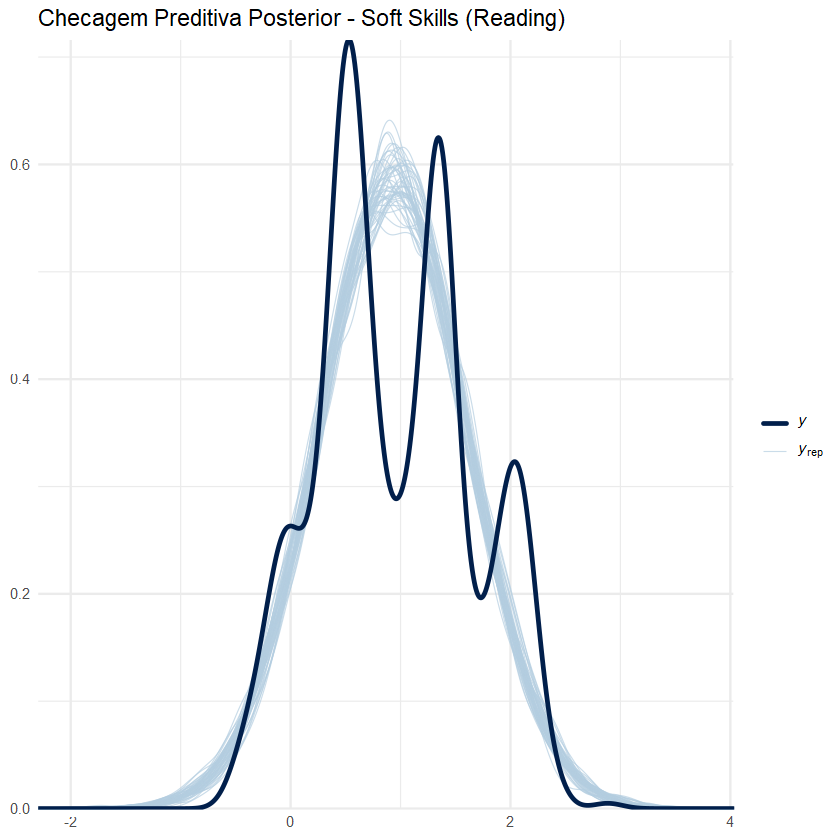

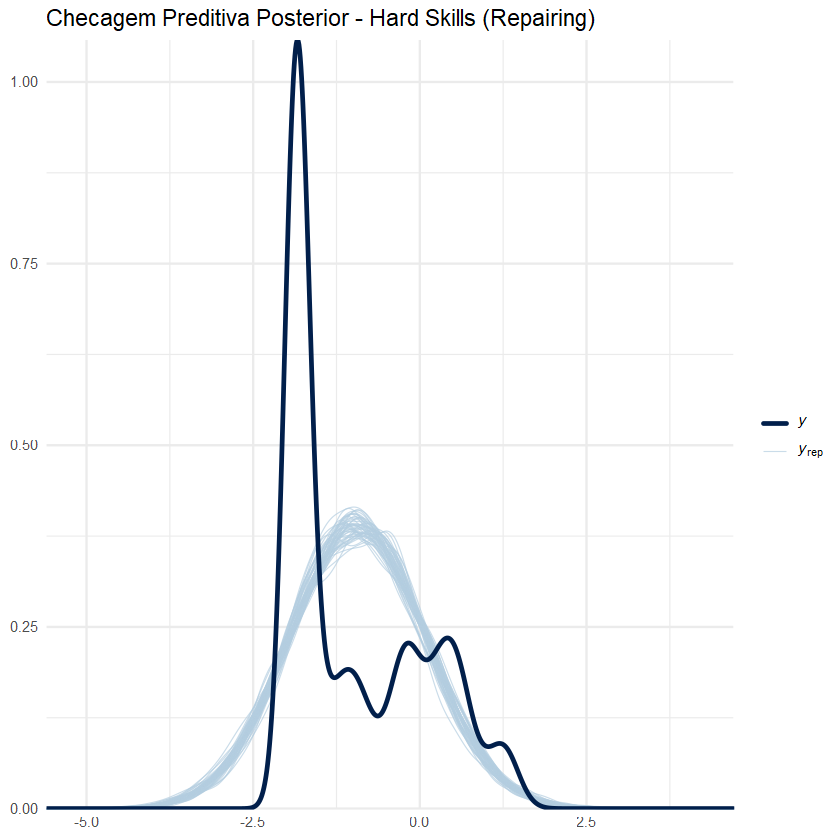

In [141]:
# --- Gráfico de Ajuste Preditivo Posterior (Substituto do PPP) ---
# Usando o nome sanitizado que o brms gerou internamente
pp_check(fit_brms_besem, resp = "ReadingComprehensionLevel", nsamples = 50) +
  theme_minimal() +
  labs(title = "Checagem Preditiva Posterior - Soft Skills (Reading)")

pp_check(fit_brms_besem, resp = "RepairingLevel", nsamples = 50) +
  theme_minimal() +
  labs(title = "Checagem Preditiva Posterior - Hard Skills (Repairing)")

In [142]:
# Extrair as médias latentes estimadas por Ano de Versão
scores_por_ano <- ranef(fit_brms_besem)$Version_Year

# Visualizar a tabela de scores (Médias e Intervalos de Credibilidade)
print(scores_por_ano)

, , ReadingComprehensionLevel_Intercept

      Estimate  Est.Error      Q2.5     Q97.5
2017 0.9294084 0.02593050 0.8783043 0.9807482
2019 0.9303122 0.02658908 0.8785137 0.9825922
2021 0.9316376 0.02651149 0.8798099 0.9834684
2023 0.9303451 0.02693533 0.8783281 0.9829894
2025 0.9329493 0.02679087 0.8806561 0.9856021

, , WritingLevel_Intercept

      Estimate  Est.Error      Q2.5     Q97.5
2017 0.6540950 0.02665093 0.6026472 0.7074155
2019 0.6543706 0.02739732 0.6009246 0.7087141
2021 0.6586981 0.02720350 0.6054060 0.7126335
2023 0.6624769 0.02747445 0.6096137 0.7165936
2025 0.6623253 0.02748741 0.6083752 0.7168961

, , SpeakingLevel_Intercept

      Estimate  Est.Error      Q2.5     Q97.5
2017 0.8048137 0.02263441 0.7615871 0.8501555
2019 0.8137919 0.02318493 0.7679309 0.8606709
2021 0.8220739 0.02312463 0.7774035 0.8679966
2023 0.8269531 0.02335069 0.7813422 0.8726012
2025 0.8269960 0.02334220 0.7820753 0.8731674

, , ScienceLevel_Intercept

       Estimate  Est.Error       Q2.5      

In [ ]:
# Extrai as médias latentes estimadas para cada combinação de Ocupação/Ano
scores_fatoriais <- ranef(fit_brms_besem)

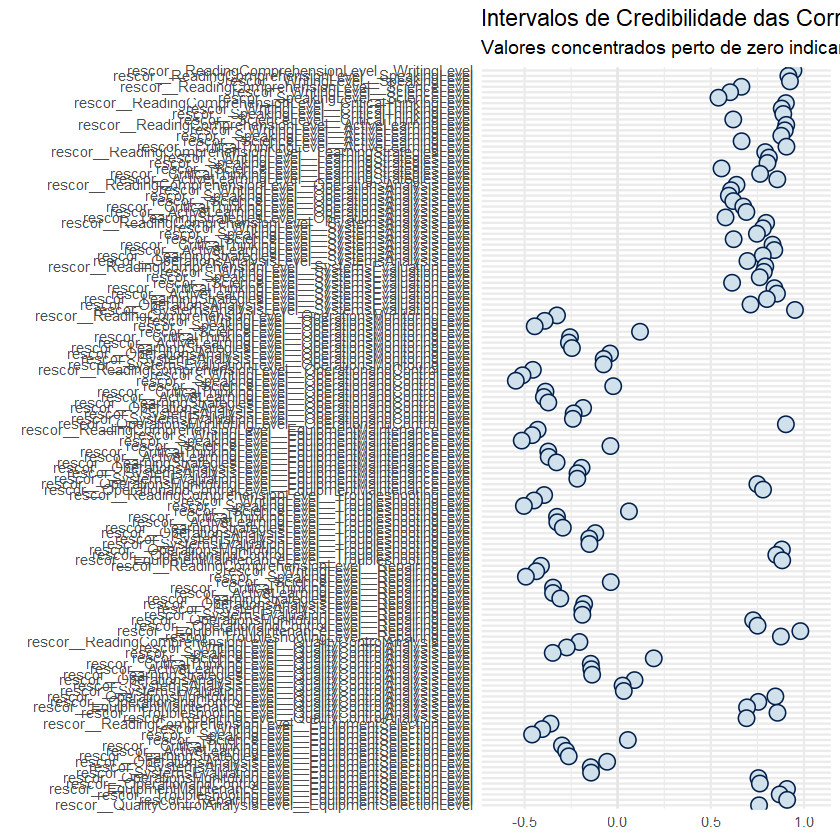

In [143]:
# 1. Extrair as estimativas das correlações residuais (rescor)
posteriori_rescor <- as.matrix(fit_brms_besem, variable = "^rescor__", regex = TRUE)

# 2. Calcular a média da posteriori para cada correlação
matriz_rescor_media <- colMeans(posteriori_rescor)

# 3. Mudar o formato para uma matriz 17x17 para plotar
# O brms nomeia como rescor__variavel1__variavel2
# Podemos usar o pacote 'GGally' ou o próprio 'bayesplot' para visualizar as distribuições
mcmc_intervals(posteriori_rescor) + 
  theme_minimal() + 
  labs(title = "Intervalos de Credibilidade das Correlações Residuais",
       subtitle = "Valores concentrados perto de zero indicam bom ajuste do fator macro")

In [148]:
# Escolhendo Reading (Soft) e Repairing (Hard) para checar as cadeias
stan_trace <- plot(fit_brms_besem, pars = c("b_ReadingComprehensionLevelIntercept", 
                                            "b_RepairingLevelIntercept"))
print(stan_trace)

Warning message:
"Argument 'pars' is deprecated. Please use 'variable' instead."


ERROR: [1m[33mError[39m in `plot.brmsfit()`:[22m
[33m![39m No valid variables selected.


Warning message:
"Argument 'nsamples' is deprecated. Please use argument 'ndraws' instead."


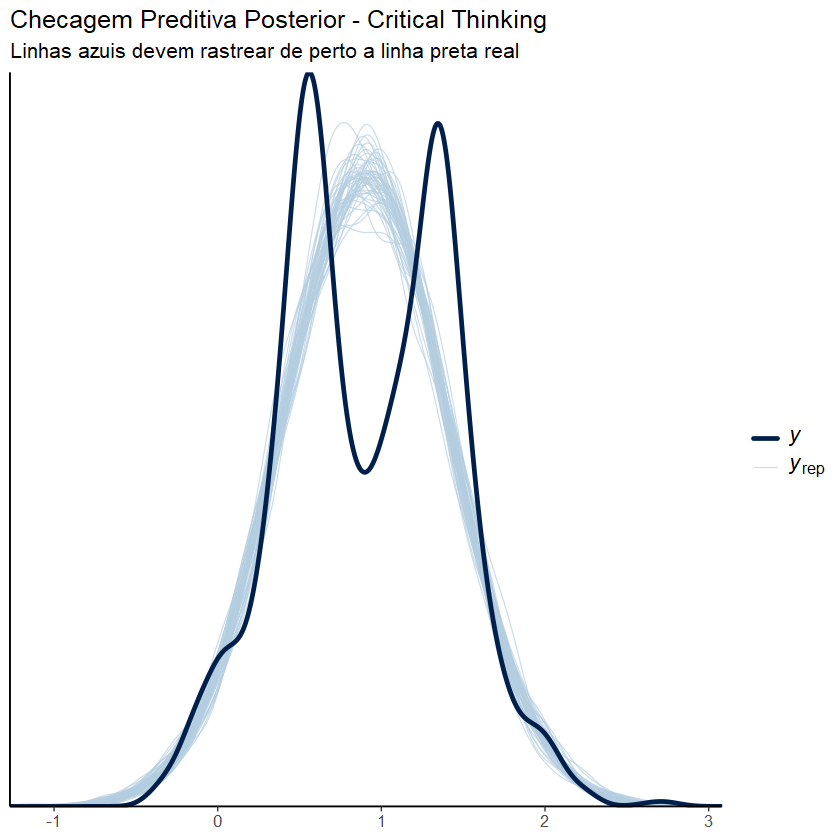

In [146]:
# Plota a densidade dos dados reais (linha preta) vs simulados (várias linhas azuis)
pp_check(fit_brms_besem, resp = "CriticalThinkingLevel", nsamples = 50) +
  labs(title = "Checagem Preditiva Posterior - Critical Thinking",
       subtitle = "Linhas azuis devem rastrear de perto a linha preta real")

### BCFA de 3 Fatores

In [ ]:
# 1. Especificação do Modelo de 3 Fatores com Pequenas Cargas Cruzadas (BSEM)
modelo_3fatores <- '
  # Definição dos Fatores Principais
  Cognitivo =~ Reading_Comprehension_Level + Writing_Level + Speaking_Level + 
               Critical_Thinking_Level + Active_Learning_Level + Learning_Strategies_Level
               
  Tecnico   =~ Science_Level + Operation_and_Control_Level + Equipment_Maintenance_Level + 
               Troubleshooting_Level + Repairing_Level + Equipment_Selection_Level
               
  Sistemas  =~ Operations_Analysis_Level + Systems_Analysis_Level + 
               Systems_Evaluation_Level + Operations_Monitoring_Level + Quality_Control_Analysis_Level

  # Priors Bayesianos de Variância Pequena para tolerar ruídos (Cargas Cruzadas)
  # Isso diz ao R que os itens podem flutuar levemente fora do seu fator principal
  # Substitui o "Zero Rígido" do CFA tradicional que inflava seu RMSEA
  
  # Exemplo de configuração de priors no blavaan (ajuste conforme os nomes das variáveis)
  # Reading_Comprehension_Level ~ prior("normal(0, 0.01)")*Tecnico + prior("normal(0, 0.01)")*Sistemas
'

# 2. Execução do BCFA Hierárquico Multinível
fit_3fatores <- bcfa(modelo_3fatores, 
                     data = esem_data, 
                     cluster = "Version_Year",
                     std.lv = TRUE) # Padroniza os fatores latentes para facilitar convergência

Computing post-estimation metrics (including lvs if requested)...


In [ ]:
# 3. Verificação dos Novos Índices de Ajuste
fit_valores_3f <- blavFitIndices(fit_3fatores)
summary(fit_valores_3f)